# Estrazione di picchi su tutto il dataset

In [78]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from lib.readwav import readwav
import ipywidgets as widgets
import json

In [79]:
%matplotlib widget
plt.close('all')

In [80]:
base_dir = "dati_processati"
spettri_dir = "spettri/"

dir = os.path.join(base_dir, spettri_dir)

available_files = [f for f in os.listdir(dir) if f.endswith('.npz')]
note_inds = [int(f.split('_')[1].split(".")[0]) for f in available_files]

print("Available files:")
for f, note_ind in zip(available_files, note_inds):
    print(f"File: {f}, Note Index: {note_ind}")

Available files:
File: note_135.wav_spectrum.npz, Note Index: 135
File: note_17.wav_spectrum.npz, Note Index: 17
File: note_206.wav_spectrum.npz, Note Index: 206
File: note_247.wav_spectrum.npz, Note Index: 247
File: note_132.wav_spectrum.npz, Note Index: 132
File: note_196.wav_spectrum.npz, Note Index: 196
File: note_76.wav_spectrum.npz, Note Index: 76
File: note_4.wav_spectrum.npz, Note Index: 4
File: note_110.wav_spectrum.npz, Note Index: 110
File: note_78.wav_spectrum.npz, Note Index: 78
File: note_128.wav_spectrum.npz, Note Index: 128
File: note_73.wav_spectrum.npz, Note Index: 73
File: note_193.wav_spectrum.npz, Note Index: 193
File: note_236.wav_spectrum.npz, Note Index: 236
File: note_237.wav_spectrum.npz, Note Index: 237
File: note_242.wav_spectrum.npz, Note Index: 242
File: note_118.wav_spectrum.npz, Note Index: 118
File: note_58.wav_spectrum.npz, Note Index: 58
File: note_111.wav_spectrum.npz, Note Index: 111
File: note_81.wav_spectrum.npz, Note Index: 81
File: note_252.wav_

In [81]:
# sort files by note index
sorted_files = [f for _, f in sorted(zip(note_inds, available_files))]
sorted_note_inds = sorted(note_inds)

In [ ]:
out_dict = {}

for filename, note_ind in zip(sorted_files, sorted_note_inds):
    data = np.load(os.path.join(dir, filename))
    freqs = data['freqs']
    avg_spectrum = data['avg_spectrum']
    mags = np.abs(avg_spectrum)

    spectrum = 10 * np.log10(avg_spectrum)
    peaks, _ = sp.signal.find_peaks(spectrum, prominence = 20)

    # se non trovi almeno 3 picchi, riduci la prominenza e riprova
    prom = 20
    while len(peaks) < 3 and prom > 0:
        prom -= 1
        peaks, _ = sp.signal.find_peaks(spectrum, prominence = prom)    
        

    peak_freqs = freqs[peaks] # Prendi solo i primi 10 picchi
    peak_mags = mags[peaks]

    out_dict[f"Nota_{note_ind}"] = {
        "peaks": {
            'frequencies': list(peak_freqs),
            'magnitudes': list(peak_mags)
        }
    }

    print(f"Processed {filename}: Found {len(peaks)} peaks")


Processed note_1.wav_spectrum.npz: Found 14 peaks
Processed note_2.wav_spectrum.npz: Found 10 peaks
Processed note_3.wav_spectrum.npz: Found 5 peaks
Processed note_4.wav_spectrum.npz: Found 96 peaks
Processed note_5.wav_spectrum.npz: Found 85 peaks
Processed note_6.wav_spectrum.npz: Found 9 peaks
Processed note_7.wav_spectrum.npz: Found 22 peaks
Processed note_8.wav_spectrum.npz: Found 26 peaks
Processed note_9.wav_spectrum.npz: Found 15 peaks
Processed note_10.wav_spectrum.npz: Found 78 peaks
Processed note_11.wav_spectrum.npz: Found 16 peaks
Processed note_12.wav_spectrum.npz: Found 8 peaks
Processed note_13.wav_spectrum.npz: Found 26 peaks
Processed note_14.wav_spectrum.npz: Found 10 peaks
Processed note_15.wav_spectrum.npz: Found 18 peaks
Processed note_16.wav_spectrum.npz: Found 10 peaks
Processed note_17.wav_spectrum.npz: Found 3 peaks
Processed note_18.wav_spectrum.npz: Found 7 peaks
Processed note_19.wav_spectrum.npz: Found 4 peaks
Processed note_20.wav_spectrum.npz: Found 4 pe

In [83]:
output_file = f"{base_dir}/{spettri_dir.replace('/', '_')}peaks.json" # salva i picchi in un file JSON

with open(output_file, 'w') as f:
    json.dump(out_dict, f, indent=4)

Dropdown(description='Nota:', options=('note_1.wav_spectrum.npz', 'note_2.wav_spectrum.npz', 'note_3.wav_spect…

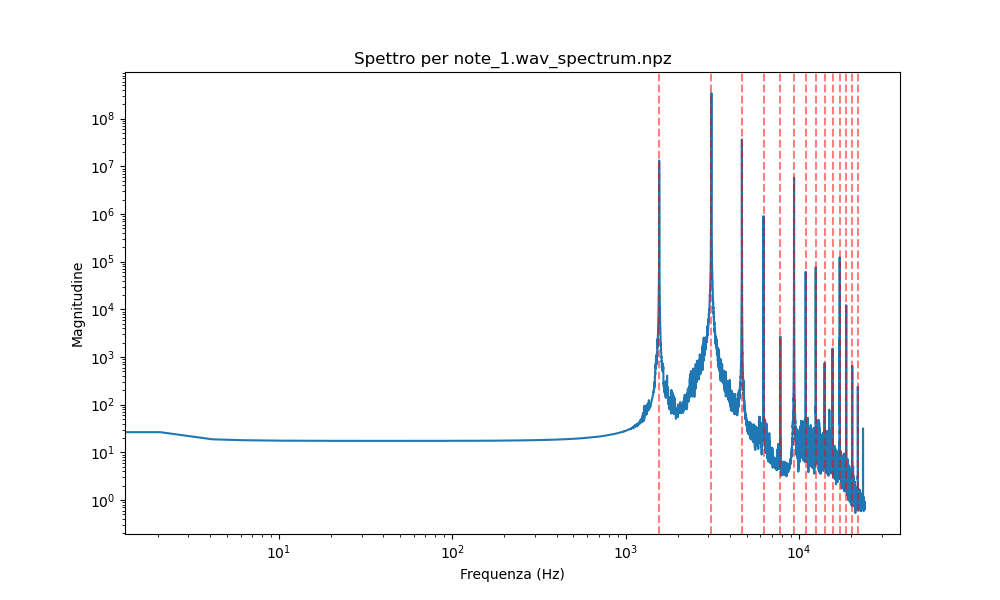

In [84]:
note_selector = widgets.Dropdown(
    options=sorted_files,
    description='Nota:',
)

fig, ax = plt.subplots()
fig.set_size_inches(10, 6)

def update_plot(change):

    filename = change["new"]
    
    data = np.load(os.path.join(base_dir, spettri_dir, filename))
    freqs = data['freqs']
    avg_spectrum = data['avg_spectrum']
    mags = np.abs(avg_spectrum)

    peaks = out_dict[f"Nota_{int(filename.split('_')[1].split('.')[0])}"]["peaks"]
    peaks = np.array(peaks['frequencies'])

    ax.clear()

    ax.plot(freqs, mags)
    
    for peak in peaks:
        ax.axvline(peak, color='red', linestyle='--', alpha=0.5)

    ax.set_title(f"Spettro per {filename}")
    ax.set_xlabel("Frequenza (Hz)")
    ax.set_ylabel("Magnitudine")

    ax.set_xscale('log')
    ax.set_yscale('log')



note_selector.observe(update_plot, names='value')
display(note_selector)
update_plot({'new': note_selector.value})